# 06 — What the analyst sees: a BOUNDED query result

An analyst asks a simple question: **"Show me revenue by day, as of June 9."**

What they don't know: the data retention policy deleted the first four days
of order history last week. This notebook shows exactly what lands on their
screen — a readable report that includes the missing days instead of
pretending they never happened.

*(Run with the repo `.venv` kernel — `pip install -e ".[all]"`.)*

In [1]:
# --- Build the situation: 10 days of orders, then the retention job runs ---
import shutil, time, json
from pathlib import Path
from datetime import datetime, timezone, date, timedelta
import pandas as pd
from deltalake import DeltaTable, write_deltalake
import alethe

WS = Path("bounded_workspace")
if WS.exists():
    shutil.rmtree(WS)
WS.mkdir()
ORDERS = WS / "orders"
DATES = [date(2026, 6, 1) + timedelta(days=d) for d in range(10)]

for d in range(10):
    write_deltalake(ORDERS, pd.DataFrame({
        "day":      [d] * 3,
        "order_id": [f"D{d}-{i}" for i in range(3)],
        "amount":   [round(100.0 * (d + 1) + i * 10, 2) for i in range(3)],
    }), mode="append")
    time.sleep(1.0)

DeltaTable(str(ORDERS)).delete("day < 4")     # retention policy: purge June 1-4
removed = DeltaTable(str(ORDERS)).vacuum(
    retention_hours=0, enforce_retention_duration=False, dry_run=False)

wm = alethe.watermark(ORDERS)
print(f"10 days of orders written (June 1-10). Retention job deleted "
      f"June 1-4 and destroyed {len(removed)} files.")
print(f"alethe watermark: boundary v{wm.boundary['version']}, "
      f"empirically validated: {wm.empirically_validated}")

10 days of orders written (June 1-10). Retention job deleted June 1-4 and destroyed 4 files.
alethe watermark: boundary v10, empirically validated: True


## Without alethe: the query just breaks

The analyst runs their time-travel query. The engine's own log says June 9
is available. It is not.

In [2]:
def commit_time(version: int) -> datetime:
    log = ORDERS / "_delta_log" / f"{version:020d}.json"
    for line in log.read_text().splitlines():
        a = json.loads(line)
        if "commitInfo" in a:
            return datetime.fromtimestamp(a["commitInfo"]["timestamp"] / 1000,
                                          tz=timezone.utc)

as_of = commit_time(8)   # "as of June 9"
try:
    dt = DeltaTable(str(ORDERS))
    dt.load_as_version(as_of)
    dt.to_pyarrow_table()
except FileNotFoundError:
    print("SELECT * FROM orders TIMESTAMP AS OF '2026-06-09'")
    print("\n❌ FileNotFoundError: part-00001-...snappy.parquet not found")
    print("\nThat's the whole user experience. A stack trace — or on some")
    print("engines, a smaller result with no hint that anything is missing.")

SELECT * FROM orders TIMESTAMP AS OF '2026-06-09'

❌ FileNotFoundError: part-00001-...snappy.parquet not found

That's the whole user experience. A stack trace — or on some
engines, a smaller result with no hint that anything is missing.


## With alethe: the report the analyst actually gets

Same question. The surviving days show real numbers. The deleted days are
**in the report** — greyed out, clearly labelled — instead of silently
gone.

In [3]:
from IPython.display import Markdown, display

# The surviving evidence, aggregated per day
surviving = (DeltaTable(str(ORDERS)).to_pyarrow_table().to_pandas()
             .query("day <= 8")
             .groupby("day", as_index=False)
             .agg(orders=("order_id", "size"), revenue=("amount", "sum")))

rows = []
for d in range(9):                      # June 1 through June 9
    match = surviving[surviving.day == d]
    if len(match):
        rows.append({"Date": DATES[d].strftime("%b %d"),
                     "Orders": int(match.orders.iloc[0]),
                     "Revenue": float(match.revenue.iloc[0]),
                     "Status": "✓ verified"})
    else:
        rows.append({"Date": DATES[d].strftime("%b %d"),
                     "Orders": None, "Revenue": None,
                     "Status": "deleted by retention"})
result = pd.DataFrame(rows)

def style_rows(row):
    if row.Status == "deleted by retention":
        return ["background-color:#f2f2f2; color:#a0a0a0; font-style:italic"] * 4
    return ["background-color:#f0f9f0"] * 4

styled = (result.style
          .apply(style_rows, axis=1)
          .format({"Revenue": lambda v: "—" if pd.isna(v) else f"${v:,.0f}",
                   "Orders":  lambda v: "—" if pd.isna(v) else f"{int(v)}"})
          .hide(axis="index")
          .set_caption("Revenue by day — as of June 9, 2026")
          .set_table_styles([
              {"selector": "caption",
               "props": "font-size:1.1em; font-weight:bold; padding:8px;"},
              {"selector": "th",
               "props": "text-align:left; padding:6px 14px; border-bottom:2px solid #ccc;"},
              {"selector": "td",
               "props": "text-align:left; padding:6px 14px;"},
          ]))
display(styled)

Date,Orders,Revenue,Status
Jun 01,—,—,deleted by retention
Jun 02,—,—,deleted by retention
Jun 03,—,—,deleted by retention
Jun 04,—,—,deleted by retention
Jun 05,3,"$1,530",✓ verified
Jun 06,3,"$1,830",✓ verified
Jun 07,3,"$2,130",✓ verified
Jun 08,3,"$2,430",✓ verified
Jun 09,3,"$2,730",✓ verified


In [4]:
total = surviving.revenue.sum()
n_missing = int(result.Status.eq("deleted by retention").sum())

display(Markdown(f"""
### Total revenue, June 1–9: **at least ${total:,.0f}**

> ⚠️ **{n_missing} of 9 days (June 1–4) were deleted by the data retention
> policy** and are not included in this total. Because orders can only add
> revenue, the true total is **higher than ${total:,.0f} — never lower.**
>
> *Source: `delta://orders`, verified boundary v{wm.boundary['version']} · full audit
> record in the watermark manifest.*
"""))


### Total revenue, June 1–9: **at least $10,650**

> ⚠️ **4 of 9 days (June 1–4) were deleted by the data retention
> policy** and are not included in this total. Because orders can only add
> revenue, the true total is **higher than $10,650 — never lower.**
>
> *Source: `delta://orders`, verified boundary v10 · full audit
> record in the watermark manifest.*


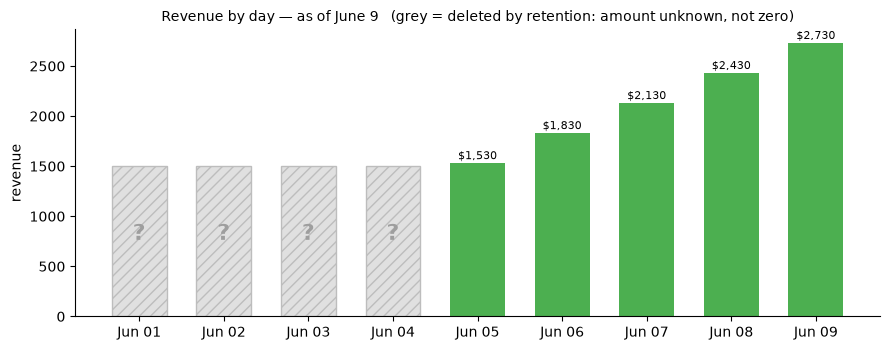

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 3.6))
known_max = result.Revenue.max()
for i, row in result.iterrows():
    if row.Status == "✓ verified":
        ax.bar(row.Date, row.Revenue, color="#4caf50", width=0.65)
        ax.text(i, row.Revenue + 40, f"${row.Revenue:,.0f}",
                ha="center", fontsize=8)
    else:
        ax.bar(row.Date, known_max * 0.55, color="#e0e0e0",
               width=0.65, hatch="///", edgecolor="#bdbdbd")
        ax.text(i, known_max * 0.28, "?", ha="center",
                fontsize=16, color="#9e9e9e", fontweight="bold")
ax.set_title("Revenue by day — as of June 9   "
             "(grey = deleted by retention: amount unknown, not zero)",
             fontsize=10)
ax.set_ylabel("revenue")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("img_bounded_bars.png", dpi=130, bbox_inches="tight")
plt.show()

That's the whole idea in one picture: **the grey bars are questions, not
zeros.** A normal chart would either crash or draw nothing for June 1–4 —
and "nothing" reads as "no sales," which is a lie.

---

## One caveat that matters: "at least" only works for some tables

The floor was safe because orders **accumulate** — deleting old ones can
only remove revenue from view. Tables that get **replaced** each load
(account balances, inventory levels) don't work that way. There, the
honest report shows the closest surviving day and says so:

In [6]:
OVR = WS / "balances"
for v, bal in enumerate([500.0, 800.0, 300.0, 650.0]):   # moves up AND down
    write_deltalake(OVR, pd.DataFrame({"account": ["A-1042"], "balance": [bal],
                                       "day": [v]}), mode="overwrite")
    time.sleep(1.0)
DeltaTable(str(OVR)).vacuum(retention_hours=0,
                            enforce_retention_duration=False, dry_run=False)
wm_b = alethe.watermark(OVR)
bv = wm_b.boundary["version"]
shown = DeltaTable(str(OVR), version=bv).to_pyarrow_table().to_pandas()

card = pd.DataFrame([{
    "Account": "A-1042",
    "You asked for": "balance on June 2",
    "Showing": f"${shown.balance.iloc[0]:,.0f}",
    "From": f"June {int(shown.day.iloc[0]) + 1} (closest surviving day)",
    "Note": "June 2 was deleted by retention. Its true balance is "
            "unrecoverable and may have been higher or lower.",
}])
(card.style.hide(axis="index")
 .set_caption("Account balance — closest available answer")
 .set_table_styles([
     {"selector": "caption", "props": "font-size:1.05em; font-weight:bold; padding:8px;"},
     {"selector": "th", "props": "text-align:left; padding:6px 12px; border-bottom:2px solid #ccc;"},
     {"selector": "td", "props": "text-align:left; padding:6px 12px; max-width:340px;"},
 ]))

Account,You asked for,Showing,From,Note
A-1042,balance on June 2,$650,June 4 (closest surviving day),June 2 was deleted by retention. Its true balance is unrecoverable and may have been higher or lower.


*(For the record: the deleted June 2 balance was $800 — the shown $650 is
neither a floor nor a ceiling. That's why this presentation says "closest
surviving day" instead of "at least.")*

---

## Under the hood (for the geeks)

Everything above is driven by three mechanical pieces — no analyst ever
needs to see these, but this is where the guarantees come from:

In [7]:
# 1. The verdict that triggered the BOUNDED presentation
v = alethe.verdict(wm, since=as_of)
print("1. verdict :", v)

# 2. The zone map that classifies any requested date
report = alethe.pit_report("orders", [wm])
zone = report.query(as_of)
print("2. zone    :", zone.status.value, "— limiting:", zone.limiting_chains)

# 3. The algebra that keeps missing rows visible through joins:
#    below the boundary, every known row-shape becomes a BEYOND 'candidate'
#    that taints joins (min) and survives projection (max) — which is why
#    the grey rows can't silently vanish from a GROUP BY.
from alethe import TemporalTable, split_result
t = TemporalTable("orders_daily", ("day", "revenue"), ("day",),
                  retention_watermark=4)
for r in surviving.itertuples():
    t.insert_version((r.day, float(r.revenue)), valid_from=r.day)
for d in range(4):
    t.insert_version((d, None), valid_from=d)
res = split_result(t.as_of(2))
print(f"3. algebra : query before the boundary → {len(res.refusals.data)} "
      f"BEYOND candidates, refused={res.refused}")

1. verdict : Verdict(BOUNDED, limiting=['delta://orders'])
2. zone    : BOUNDED — limiting: ['delta://orders']
3. algebra : query before the boundary → 9 BEYOND candidates, refused=True
